<a href="https://colab.research.google.com/github/Evelyn-Rojas/Procesos-Estocasticos/blob/main/DescomposicionCanonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="mediumslateblue"> **Evelyn Tania Rojas Roa**

<font color="mediumslateblue">**Procesos Estocásticos**

---


# <font color="magenta">**Descomposición Canónica**

---



> La descomposición canónica de una matriz (también conocida comúnmente como la Forma Canónica de Jordan) es un proceso mediante el cual se busca representar una matriz cuadrada de la manera más simple posible a través de un cambio de base, sin perder sus propiedades fundamentales.

Dada una matriz cuadrada $A \in \mathbb{C}^{n \times n}$, la descomposición consiste en encontrar una matriz invertible $P$ tal que:$$A = P J P^{-1}$$Donde $J$ es la Matriz de Jordan. Esta matriz $J$ tiene una estructura de bloques en su diagonal principal:$$J = \begin{pmatrix} J_1 & 0 & \dots & 0 \\ 0 & J_2 & \dots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \dots & J_k \end{pmatrix}$$

Cada bloque $J_i$ corresponde a un autovalor (valor propio) $\lambda_i$. Un bloque de Jordan tiene la siguiente forma característica:
* El autovalor $\lambda$ en la diagonal principal.
* Unos (1) justo por encima de la diagonal (superdiagonal).
* Ceros en el resto de las posiciones.

><font color="darkviolet"> **1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.**

In [48]:
#Importamos las librerias necesarias
import numpy as np
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt
import graphviz

In [49]:
# Definición de la matriz de transición P ¿
P = sp.Matrix([
    [1/4, 0,   0,   0,   0,   0,   3/4], # a
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8], # b
    [0,   0,   2/5, 1/5, 2/5, 0,   0],   # c
    [0,   0,   1/2, 1/2, 0,   0,   0],   # d
    [0,   0,   0,   1/2, 1/2, 0,   0],   # e
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5], # f
    [4/5, 0,   0,   0,   0,   0,   1/5]  # g
])

P

Matrix([
[ 0.25,     0,    0,   0,    0,     0,  0.75],
[0.125, 0.125, 0.25,   0, 0.25, 0.125, 0.125],
[    0,     0,  0.4, 0.2,  0.4,     0,     0],
[    0,     0,  0.5, 0.5,    0,     0,     0],
[    0,     0,    0, 0.5,  0.5,     0,     0],
[    0,   0.2,    0, 0.2,  0.2,   0.2,   0.2],
[  0.8,     0,    0,   0,    0,     0,   0.2]])

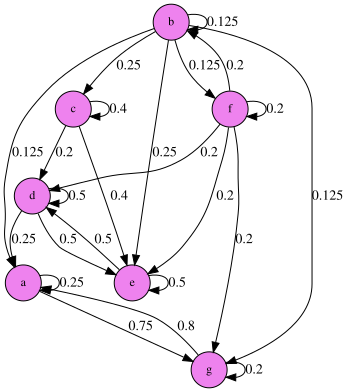

In [50]:
dot = graphviz.Digraph() #Nos permite hacer el diagrama de una forma más ordenada y legible
dot.attr('node', shape='circle', style='filled',
         fillcolor='violet', fontsize='12')

dot.node('E1', 'a')
dot.node('E2', 'b')
dot.node('E3', 'c')
dot.node('E4', 'd')
dot.node('E5', 'e')
dot.node('E6', 'f')
dot.node('E7', 'g')

transiciones = [
    ('E1','E1','0.25'),
    ('E1','E7','0.75'),
    ('E2','E1','0.125'),
    ('E2','E2','0.125'),
    ('E2','E3','0.25'),
    ('E2','E5','0.25'),
    ('E2','E6','0.125'),
    ('E2','E7','0.125'),
    ('E3','E3','0.4'),
    ('E3','E4','0.2'),
    ('E3','E5','0.4'),
    ('E4','E1','0.25'),
    ('E4','E4','0.5'),
    ('E4','E5','0.5'),
    ('E5','E4','0.5'),
    ('E5','E5','0.5'),
    ('E6','E2','0.2'),
    ('E6','E4','0.2'),
    ('E6','E5','0.2'),
    ('E6','E6','0.2'),
    ('E6','E7','0.2'),
    ('E7','E1','0.8'),
    ('E7','E7','0.2'),
]

for origen, destino, prob in transiciones:
    if prob != '0':
        dot.edge(origen, destino, label=prob)

dot

><font color="mediumpurple">**2. Determine si la matriz tiene o no distribución límite.**

Una cadena tiene distribución límite si, independientemente del estado inicial:

$$ \lim_{n \to \infty} P^n = \Pi $$

y todas las filas de $\Pi$ son iguales (la distribución estacionaria). Esto pasa si la cadena es:

*   **Irreducible** (todos los estados se comunican).
*   **Aperiódica**.

Una forma rápida de saber si tiene distribución límite es verificando si es positiva.

Una matriz $A$ de tamaño $m \times n$ se dice que es **positiva** si todas sus entradas son estrictamente mayores que cero. Se denota como:

$$ A > 0 \iff a_{ij} > 0 $$

para todo $i \in \{1, \dots, m\}$ y $j \in \{1, \dots, n\}$.

In [51]:
#Obtendremos algunas potencias de nuestra matriz P para verificar
P2=P**2
P2

Matrix([
[  0.6625,        0,       0,    0,       0,        0,   0.3375],
[0.146875, 0.040625, 0.13125,  0.2, 0.28125, 0.040625, 0.159375],
[       0,        0,    0.26, 0.38,    0.36,        0,        0],
[       0,        0,    0.45, 0.35,     0.2,        0,        0],
[       0,        0,    0.25,  0.5,    0.25,        0,        0],
[   0.185,    0.065,    0.15, 0.24,    0.19,    0.065,    0.105],
[    0.36,        0,       0,    0,       0,        0,     0.64]])

In [52]:
P10=P**10
P10

Matrix([
[0.517354654010254,                   0,                 0,                 0,                 0,                   0, 0.482645345989746],
[0.171988654922658, 5.05661934518814e-6, 0.222173673923512, 0.266708044001801, 0.177778206582227, 5.05661934518814e-6, 0.161341307331112],
[                0,                   0,      0.3333117166,      0.4000406558,      0.2666476276,                   0,                 0],
[                0,                   0,      0.3333095345,      0.3999736235,       0.266716842,                   0,                 0],
[                0,                   0,      0.3333960525,       0.399988745,      0.2666152025,                   0,                 0],
[  0.1724017220618, 8.09059095230103e-6,  0.22220883367762, 0.266664125602881, 0.177782919931563, 8.09059095230103e-6, 0.160926217544232],
[0.514821702389063,                   0,                 0,                 0,                 0,                   0, 0.485178297610938]])

Nuestra matriz no es positva por lo que no tendremos dístribución límite.

><font color="mediumpurple">**3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.**

**Clases de comunicación:**
* {b,f}, transitoria
* {g,a}, recurrente
* {c,d,e}, recurrente

La CM es irreducible, no ergódica, no regular, estocástica.

><font color="mediumpurple">**4. Escriba un programa que encuentre la descomposición canónica de una matriz dada.**

In [53]:
def descomposicion_canonica(P):
    n = P.rows

    # Crear grafo dirigido
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i, j] != 0:
                G.add_edge(i, j)

    # Componentes fuertemente conexas
    scc = list(nx.strongly_connected_components(G))

    recurrentes = []
    transientes = []

    # Clasificamos las clases
    for comp in scc:
        es_cerrada = True
        for i in comp:
            for j in range(n):
                if j not in comp and P[i, j] != 0:
                    es_cerrada = False

        if es_cerrada:
            recurrentes.extend(comp)
        else:
            transientes.extend(comp)

    # Reordenamos la matriz
    nuevo_orden = transientes + recurrentes

    # Reordenar matriz
    P_reordenada = P.extract(nuevo_orden, nuevo_orden)

    t = len(transientes)

    # Submatrices
    Q = P_reordenada[:t, :t]
    R = P_reordenada[:t, t:]
    S = P_reordenada[t:, t:]

    return {
        "orden": nuevo_orden,
        "transientes": transientes,
        "recurrentes": recurrentes,
        "P_canonica": P_reordenada,
        "Q": Q,
        "R": R,
        "S": S
    }

In [54]:
resultado = descomposicion_canonica(P)

print("Orden nuevo:", resultado["orden"])
print("Estados transientes:", resultado["transientes"])
print("Estados recurrentes:", resultado["recurrentes"])

print("\nMatriz canónica:")
sp.pprint(resultado["P_canonica"])

print("\nQ:")
sp.pprint(resultado["Q"])

print("\nR:")
sp.pprint(resultado["R"])

print("\nS:")
sp.pprint(resultado["S"])

Orden nuevo: [1, 5, 0, 6, 2, 3, 4]
Estados transientes: [1, 5]
Estados recurrentes: [0, 6, 2, 3, 4]

Matriz canónica:
⎡0.125  0.125  0.125  0.125  0.25   0   0.25⎤
⎢                                           ⎥
⎢ 0.2    0.2     0     0.2    0    0.2  0.2 ⎥
⎢                                           ⎥
⎢  0      0    0.25   0.75    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0     0.8    0.2    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.4   0.2  0.4 ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.5   0.5   0  ⎥
⎢                                           ⎥
⎣  0      0      0      0     0    0.5  0.5 ⎦

Q:
⎡0.125  0.125⎤
⎢            ⎥
⎣ 0.2    0.2 ⎦

R:
⎡0.125  0.125  0.25   0   0.25⎤
⎢                             ⎥
⎣  0     0.2    0    0.2  0.2 ⎦

S:
⎡0.25  0.75   0    0    0 ⎤
⎢                         ⎥
⎢0.8   0.2    0    0    0 ⎥
⎢                         ⎥
⎢ 0     0    0.4  0

In [55]:
#Distribución estacionaria
S=resultado["S"]
def estacionaria(M):
    n = M.rows
    A = (M - sp.eye(n)).T
    ns = A.nullspace()[0]
    return ns / sum(ns)

pi_S = estacionaria(S)
print("Distribución estacionaria de S:")
sp.pprint(pi_S)

Distribución estacionaria de S:
⎡0.516129032258065⎤
⎢                 ⎥
⎢0.483870967741936⎥
⎢                 ⎥
⎢        0        ⎥
⎢                 ⎥
⎢        0        ⎥
⎢                 ⎥
⎣        0        ⎦


In [56]:
#Matriz fundamental
Q=resultado["Q"]
I = sp.eye(Q.rows)
N = (I - Q).inv()

In [57]:
#Probabilidades de adsorción
R=resultado["R"]
B = N * R
print("Matriz de absorción B:")
sp.pprint(B)

Matriz de absorción B:
⎡0.148148148148148  0.185185185185185  0.296296296296296   0.037037037037037   ↪
⎢                                                                              ↪
⎣0.037037037037037  0.296296296296296  0.0740740740740741  0.259259259259259   ↪

↪ 0.333333333333333⎤
↪                  ⎥
↪ 0.333333333333333⎦


In [58]:
#Costruimos la límite P**n
t = Q.rows
r = S.rows

# Bloques
cero_t = sp.zeros(t, t)
cero_tr = sp.zeros(r, t)

# Pi repetida
Pi = sp.Matrix([pi_S.T for _ in range(r)])

# Matriz límite
limite = sp.Matrix.vstack(
    sp.Matrix.hstack(cero_t, B),
    sp.Matrix.hstack(cero_tr, Pi)
)

print("Límite de P^n:")
sp.pprint(limite)

Límite de P^n:
⎡0  0  0.148148148148148  0.185185185185185  0.296296296296296   0.03703703703 ↪
⎢                                                                              ↪
⎢0  0  0.037037037037037  0.296296296296296  0.0740740740740741  0.25925925925 ↪
⎢                                                                              ↪
⎢0  0  0.516129032258065  0.483870967741936          0                   0     ↪
⎢                                                                              ↪
⎢0  0  0.516129032258065  0.483870967741936          0                   0     ↪
⎢                                                                              ↪
⎢0  0  0.516129032258065  0.483870967741936          0                   0     ↪
⎢                                                                              ↪
⎢0  0  0.516129032258065  0.483870967741936          0                   0     ↪
⎢                                                                              ↪
⎣0  0  0.5161



$
\text{La matriz de transición } P \text{ admite una descomposición canónica de la forma}
$

$$
P =
\begin{pmatrix}
Q & R \\
0 & S
\end{pmatrix},
$$

$
\text{donde } Q \text{ corresponde a los estados transientes y } S \text{ a la subcadena formada por la clase cerrada irreducible.}
$

$
\text{Al analizar el comportamiento asintótico de la cadena, se obtiene que}
$

$$
\lim_{n \to \infty} P^n =
\begin{pmatrix}
0 & B \\
0 & \Pi
\end{pmatrix},
$$

$
\text{donde } \Pi \text{ es una matriz cuyas filas coinciden con la distribución estacionaria de } S.
$

$
\text{En consecuencia, la distribución límite de la cadena de Markov coincide con la distribución estacionaria de la submatriz } S
$

$
\text{lo que confirma que el comportamiento en el largo plazo está completamente determinado por la clase cerrada irreducible.}
$

$
\text{Los estados transientes tienen probabilidad nula en el límite.}
$